# 🧭 Example 1: Logistic Regression on the UCI Sonar Dataset

This notebook demonstrates how to construct and evaluate a **Logistic Regression** model for classifying sonar signals as **Rock (R)** or **Mine (M)**. The task represents a binary classification problem using the **Sonar Dataset** from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/connectionist+bench+(sonar,+mines+vs.+rocks)).

Each observation in the dataset corresponds to a sonar signal reflected either from a **metal cylinder (mine)** or a **rock**. The dataset consists of:

- **60 continuous numeric features**, each representing the energy of the reflected signal at a specific frequency band.
- **1 categorical label column**, indicating the type of object (`'R'` for rock, `'M'` for mine).


In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1) Load and Inspect the Dataset

- The dataset is loaded from a CSV file using `header=None` because it does not contain column names.  
- After loading, the overall structure, dimensionality, and a few sample rows are examined to understand the format and composition of the data.

In [ ]:
# Load the Sonar dataset from a local CSV file.
sonar = pd.read_csv("Example_1_Rock_vs_Mine_Classification.csv", header=None)

# Display the total number of rows and columns in the dataset.
print(f"Dataset shape: {sonar.shape}")

# Display the first five rows to inspect the data structure and feature values.
sonar.head()

Dataset shape: (208, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 2) Basic Dataset Exploration

This step provides an initial understanding of the dataset’s structure and quality.  
It focuses on three key aspects:

- **Class distribution:**  
  Shows how many samples belong to each category (*Rock* vs. *Mine*), helping identify any class imbalance.

- **Missing values check:**  
  Confirms that the dataset is complete and free of null entries before proceeding to model training.

- **Summary statistics:**  
  Describes the range, mean, and variability of the 60 numeric features to detect unusual values or outliers.


Class distribution:
60
M    111
R     97
Name: count, dtype: int64

Missing values:
0

Feature summary:


,count,mean,std,min,25%,50%,75%,max
0,208.0,0.029164,0.022991,0.0015,0.013350,0.02280,0.035550,0.1371
1,208.0,0.038437,0.032960,0.0006,0.016450,0.03080,0.047950,0.2339
2,208.0,0.043832,0.038428,0.0015,0.018950,0.03430,0.057950,0.3059
3,208.0,0.053892,0.046528,0.0058,0.024375,0.04405,0.064500,0.4264
4,208.0,0.075202,0.055552,0.0067,0.038050,0.06250,0.100275,0.4010


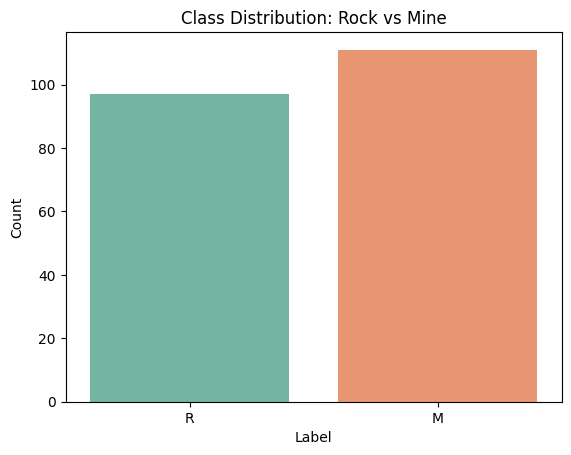

In [ ]:
# Show the number of samples in each class (R vs M)
print("\nClass distribution:")
print(sonar[60].value_counts())

# Check for missing values in the dataset
print("\nMissing values:")
print(sonar.isnull().sum().sum())

# Display basic statistics for the numeric features
print("\nFeature summary:")
display(sonar.describe().T.head())

# Assign column names for better readability
sonar.columns = [f"Feature_{i}" for i in range(60)] + ["Label"]

# Plot class distribution for visual inspection
sns.countplot(x="Label", data=sonar, palette="Set2")
plt.title("Class Distribution: Rock vs Mine")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 3) Separate Features and Labels

The dataset is divided into two components to prepare it for model training:

- **Features (X):** the first 60 columns, representing continuous numeric measurements of sonar signal energy at different frequencies.  
- **Label (y):** the final column, indicating the object category (`'R'` for Rock or `'M'` for Mine).

In [ ]:
# Extract all feature columns (first 60) and convert them to float values
X = sonar.iloc[:, :-1].astype(float)

# Extract the target label column ('R' or 'M')
y = sonar.iloc[:, -1]

# Display the shape of the feature matrix (rows × features)
print("Feature matrix shape:", X.shape)

# Display the shape of the label vector (number of samples,)
print("Label vector shape:", y.shape)

Feature matrix shape: (208, 60)
Label vector shape: (208,)


## 4) Feature Scaling

The 60 sonar signal features vary in their numerical ranges, which can cause certain attributes to dominate others during model training.  
- To ensure that all features contribute equally and to improve the stability and convergence of the optimization process, the data is standardized before training.

**Standardization** transforms each feature to have a mean of zero and a standard deviation of one, making the dataset more suitable for algorithms such as Logistic Regression, which are sensitive to feature magnitude.

Feature scaling is performed using `StandardScaler` from **scikit-learn**, which applies the transformation efficiently across all numeric columns.  

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5) Split into Training and Test Sets

The dataset is divided into two subsets to evaluate model performance on unseen data  
- **80%** of the samples are used for training, and **20%** are reserved for testing.  

The `stratify` parameter maintains the original class distribution (Rock vs. Mine) in both subsets, ensuring balanced representation and fair evaluation of the model’s predictive ability.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,           # Feature matrix after standardization (input variables)
    y,                  # Target labels ('R' for Rock, 'M' for Mine)
    test_size=0.2,      # 20% of data reserved for testing, 80% used for training
    stratify=y,         # Maintains the same class distribution (Rock vs Mine) in both sets
    random_state=42     # Ensures reproducible results each time the code runs
)

# Display the number of samples in each subset
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 166
Testing samples : 42


## 6) Train the Logistic Regression Model

Logistic Regression is a linear classification algorithm that estimates the probability of an input belonging to a particular class using the **logistic (sigmoid) function**.

The model predicts the probability that a sample belongs to class **1 (Mine)** as:
$$
P(y = 1 \mid x) = \frac{1}{1 + e^{-(w^T x + b)}}
$$

Where:  
- $x$: input feature vector (the sonar readings)  
- $w$: learned weights for each feature  
- $b$: bias or intercept term  

The output value lies between **0 and 1**, indicating the predicted probability of the positive class.  
- A threshold of 0.5 is typically used to classify the output as either Rock or Mine.


In this step, a **Logistic Regression** model is trained using the **LBFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno)** solver, which is an efficient optimization algorithm suitable for small to medium-sized datasets.  
- It is a memory-efficient variant of the BFGS method and performs well with high-dimensional data while maintaining numerical stability.

The parameter `max_iter=1000` sets the maximum number of iterations that the optimization algorithm can perform while minimizing the cost function.  
- Each iteration updates the model’s coefficients to reduce the classification error.  
- If the number of iterations is too low, the algorithm may stop before reaching the minimum loss, resulting in an **incomplete or unstable model**.  
- By setting `max_iter=1000`, the solver is allowed enough iterations to **fully converge**, ensuring that the model parameters (\(w\) and \(b\)) are optimized and the training process reaches a stable solution.


**References:**  
- [Scikit-learn: Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)  
- [Wikipedia: L-BFGS Algorithm](https://en.wikipedia.org/wiki/Limited-memory_BFGS)

In [ ]:
# Create a Logistic Regression model instance
# max_iter=1000  → sets the maximum number of optimization iterations to ensure convergence
# solver='lbfgs' → specifies the optimization algorithm (efficient for small to medium datasets)
model = LogisticRegression(max_iter=1000, solver='lbfgs')

# Train the model using the training data (features and labels)
# The model learns the optimal coefficients (weights) for each feature to best separate the classes
model.fit(X_train, y_train)

# Confirm that model training has been completed successfully
print("Model training completed successfully.")

Model training completed successfully.


## 7) Evaluate Model Performance

After training, the model’s performance is evaluated to measure how accurately it predicts unseen data.  
Several key metrics are used for this evaluation:

- **Accuracy:** The proportion of correct predictions out of all predictions made.  
- **Confusion Matrix:** A table that summarizes true positives, true negatives, false positives, and false negatives, providing insight into specific types of classification errors.  
- **Precision, Recall, and F1-Score:**  
  - **Precision** measures how many of the positive predictions are actually correct.  
  - **Recall** measures how many of the actual positives are correctly identified.  
  - **F1-Score** combines both precision and recall into a single balanced measure.

These metrics together provide a comprehensive understanding of how well the model distinguishes between Rock and Mine samples, beyond simple accuracy alone.

Training Accuracy: 0.922
Testing Accuracy : 0.833


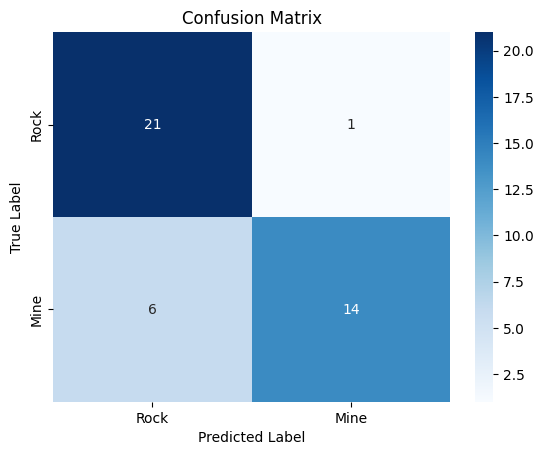


Classification Report:

              precision    recall  f1-score   support

           M       0.78      0.95      0.86        22
           R       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42



In [ ]:
# Generate predictions on both the training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# ------------------------------------------
# Calculate accuracy scores
# ------------------------------------------
# Accuracy = (Number of correct predictions) / (Total predictions)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Testing Accuracy : {test_acc:.3f}")

# ------------------------------------------
# Create and display the confusion matrix
# ------------------------------------------
# The confusion matrix provides a summary of prediction results:
# - True Positives  (TP): correctly predicted Mines
# - True Negatives  (TN): correctly predicted Rocks
# - False Positives (FP): Rocks incorrectly predicted as Mines
# - False Negatives (FN): Mines incorrectly predicted as Rocks
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Rock', 'Mine'],
            yticklabels=['Rock', 'Mine'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ------------------------------------------
# Generate a detailed classification report
# ------------------------------------------
# Includes Precision, Recall, and F1-Score for each class.
# These metrics provide deeper insight into the model’s strengths and weaknesses.
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

## 8) Predict on a Single Example

- To demonstrate how the trained model can be used in practice, a single sonar reading is selected and passed through the model for prediction.  
    - The input features are reshaped into the required format, scaled using the same transformation applied during training, and then classified as either **Rock** or **Mine**.  

In [ ]:
# ------------------------------------------
# PREDICTING ON A SINGLE EXAMPLE
# ------------------------------------------
def predict_one(feature_list):
    """
    Predict whether a sonar reading corresponds to a Rock or a Mine.

    Parameters:
        feature_list (list or array): 60 numeric feature values representing one sample.

    Returns:
        str: "Rock" or "Mine" based on the model's prediction.
    """
    import numpy as np

    # Convert the input list to a NumPy array and reshape it to match model input format (1 row, 60 columns)
    arr = np.asarray(feature_list, dtype=float).reshape(1, -1)

    # Apply the same standardization used during training
    arr_scaled = scaler.transform(arr)

    # Predict the label using the trained Logistic Regression model
    label = model.predict(arr_scaled)[0]

    # Return the readable class name
    return "Rock" if label == 'R' else "Mine"

# ------------------------------------------
# Select one example from the test set for prediction
# ------------------------------------------
# If X_test is a NumPy array, use X_test[0]
# If X_test is a DataFrame, use X_test.iloc[0].values
example = X_test[0] if not hasattr(X_test, "iloc") else X_test.iloc[0].values

# Use the function to predict the class of the selected sample
prediction = predict_one(example)

# Display the prediction result
print("Predicted Class:", prediction)

Predicted Class: Rock
